# LoVoCCS morphology: Manually assigning broad ICM morphology classes

As part of the hot-phase intra-cluster medium (ICM) morphology subsection of the X-LoVoCCS project, we manually assign broad morphology classifications to our galaxy clusters - this helps us to place our quantitative measurements of morphology (centroid-shift, concentration, cluster component offsets and alignments) into perspective. This is a qualitative process as it relies on our experience with X-ray emissions from galaxy clusters, but we think they should be a reliable place to start for our morphological analyses. 

Very little code is executed in this notebook, as it mostly acts as a place for us to examine the images, make notes, and give them their classification. Here we list the broad morphology classes we can assign (top level bullet points), and optional modifiers that can be applied to those broad classifications (indented bullet points):

### **MORPHOLOGY TAXONOMY**:

* **Centrally peaked (CeP)** - ICM that has bright (relative to the overall ICM) emission from a small region relatively close to the apparent centre of the ICM, and that appears approximately circular, without much additional structure.
    * ***Plateau (+Pl)*** - Centrally peaked emission that covers a larger fraction of the apparent size of the ICM than a typical **CP**-class.
      
<!-- spacer -->

* **Structured (S)** - X-ray emission that is not completely dominated by a bright central emission, but instead has other obvious structures such as spiral-like features, or hard drop-offs in surface brightness. Specific features can be indicated with optional modifiers (these can also be applied to the other broad morphological classes).
    * ***Sharp drop (+SD)*** - A sharp change in surface brightness, resulting in an obvious edge.
    * ***Spiral (+Sp)*** - ICM feature that resembles part of a spiral shape, commonly associated with sloshing.
    * ***Cavities (+Ca)*** - Obvious 'voids' of lower surface brightness, often close to the centre, and perhaps symmetrical - commonly associated with radio mode AGN in central galaxies.
    * ***Outer islands (+OIs)*** - Areas of increased surface brightness, moderate size compared to the overall emission but set within it, and _not_ located in the centre of the extended emission.

<!-- spacer -->

* **Multi-modal (MM)** - ICM with multiple extended components of similar size that present as extended local peaks in a wider, mingled, extended emission.
    * ***Number of components (+NC\<NUMBER\>)*** - To indicate the number of major components of the multi-modal morphology.

<!-- spacer -->

* **Featureless blob (FB)** - The opposite end of the scale from a **CeP** classification, where the ICM X-ray surface brightness emission appears almost uniform across the majority of the ICM.

## Main takeaways 

In summary:

* 

## Import Statements

In [37]:
import pandas as pd
pd.set_option('display.max_columns', 500)
from astropy.units import Quantity
import numpy as np
from matplotlib import pyplot as plt
import os
from shutil import rmtree

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '../')
from common import lovoccs_cosmo

import xga
# This just sets the number of cores this analysis is allowed to use
xga.NUM_CORES = 5
# This is a bodge that will only work because xga_output in notebooks has already been defined, XGA
#  will be made to handle this more gracefully at some point
temp_dir = xga.OUTPUT
actual_dir = temp_dir.split('notebooks/')[0]+'notebooks/xga_output/'
xga.OUTPUT = actual_dir
xga.utils.OUTPUT = actual_dir
# As currently XGA will setup an xga_output directory in our current directory, I remove it to keep it all clean
if os.path.exists('xga_output'):
    rmtree('xga_output')
from xga.samples import ClusterSample

%matplotlib inline

## Useful values

Here we set up constants that will be used throughout the notebook - in this case the allowed classification and modifier values of the ICM morphology taxonomy:

In [40]:
# The overarching broad morphology classes
BROAD_CLASS = {"CeP": "Centrally peaked", "S": "Structured", 'MM': "Multi-modal", "FB": "Featureless blob"}
# Modifiers that can be applied to the broad classes
CLASS_MODIFIERS = {"Pl": "Central plateau", ""}

## Output paths

Path to store the output manual classifications: 

In [2]:
morph_class_path = "../../outputs/results/positions_and_morphology/"
os.makedirs(morph_class_path, exist_ok=True)

## Cosmological model

We employ the same cosmological model utilized in the LoVoCCS-I & II analyses (Fu et al. [2022](https://ui.adsabs.harvard.edu/abs/2022ApJ...933...84F/abstract), [2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)):

In [3]:
lovoccs_cosmo

LambdaCDM(name=None, H0=<Quantity 71. km / (Mpc s)>, Om0=0.2648, Ode0=0.7352, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0448)

## Loading data files

Important considerations for this dataset:

* Some clusters selected for LoVoCCS have been identified as multiple blended systems in the course of the X-LoVoCCS project - other LoVoCCS works may only have entries/have made measurements for the overall system.
* Not all LoVoCCS-II galaxy clusters have XMM data available - as such we will not yet have measured X-ray centroids for them.

### X-LoVoCCS-I base sample

In [4]:
xlovoccs_base = pd.read_csv("../../sample_files/X-LoVoCCSI.csv")
xlovoccs_base.insert(0, 'name', xlovoccs_base['LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x)))
xlovoccs_base.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
3,LoVoCCS-4B,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
5,LoVoCCS-7,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44


### Combining tables

For now, we only need the information contained in the X-LoVoCCS base sample, so we do not merge it with any other tables:

In [5]:
xlovoccs_samp = xlovoccs_base

## Defining morphology classification results dataframe

We set up a table to populate with our manual classifications, notes, and other information that may impact the class we assign - this is done prior to the removal of some X-LoVoCCS entries from the sample due to limited coverage (see the 'Defining an XGA ClusterSample' section), as we wish to have entries for those clusters in the output files, even if they aren't yet covered by the telescope chosen for inspection:

In [18]:
# Preparing a dataframe to hold our classifications, notes on morphology, and other information which provides helpful context
mc_cols = ['name', 'LoVoCCSID', 'parent_LoVoCCSID', 'telescope_examined', 'SNR', 'examined_energy_band', 'proper_dist_resolution'
           'morph_class', 'morph_class_modifiers', 'morph_notes']
# Setting up the data types of the columns
mc_col_dtypes = {'name': str, 'LoVoCCSID': str, 'parent_LoVoCCSID': int, 'telescope_examined': str, 'SNR': float, 
                 'examined_energy_band': str, 'proper_dist_resolution': str, 
                 'morph_class': str, 'morph_class_modifiers': str, 'morph_notes': str}

# Make the dataframe, empty for now
morph_class = pd.DataFrame(columns=mc_cols)
# Apply the previously defined column types
morph_class = morph_class.astype(mc_col_dtypes)
# Add identifier information from the X-LoVoCCS sample
morph_class[['name', 'LoVoCCSID', 'parent_LoVoCCSID']] = xlovoccs_samp[['name', 'LoVoCCSID', 'parent_LoVoCCSID']].values

# We also set the cluster names as the index, to make it a little neater to access the rows for specific clusters when 
#  we assign information to the columns later in the notebook
morph_class = morph_class.set_index('name')
morph_class.head(6)

,LoVoCCSID,parent_LoVoCCSID,telescope_examined,SNR,examined_energy_band,morph_class,morph_class_modifiers,morph_notes
name,,,,,,,,
LoVoCCS-1,1,1,NaN,NaN,NaN,NaN,NaN,NaN
LoVoCCS-2,2,2,NaN,NaN,NaN,NaN,NaN,NaN
LoVoCCS-4A,4A,4,NaN,NaN,NaN,NaN,NaN,NaN
LoVoCCS-4B,4B,4,NaN,NaN,NaN,NaN,NaN,NaN
LoVoCCS-5,5,5,NaN,NaN,NaN,NaN,NaN,NaN
LoVoCCS-7,7,7,NaN,NaN,NaN,NaN,NaN,NaN


## Defining an XGA ClusterSample

As we do not have observation cleaning turned on, we manually remove clusters that we know are excluded from our other analyses due to inadequate XMM data:

* LoVoCCS-41C is a component of 41 we identified from ROSAT Pointed data, but it does not fall on the XMM observation.
* LoVoCCS-33 is a cluster that partially falls on the edge of an observation of a nearby object - the coverage is insufficient for any real analysis however.

In [7]:
xlovoccs_samp = xlovoccs_samp[~xlovoccs_samp['LoVoCCSID'].isin(['41C', '33'])]

We define a ClusterSample, centered on the 'start positions' we defined in the early stages of our analysis of this sample - the start positions will be the same as the MCXC positions in cases where we judged the coordinate to be adequate, but will be manually defined from modern observations if it was too far outside the main part of the ICM, or if the cluster has multiple components that went unresolved in MCXC:

In [15]:
# TODO REMOVE OBVIOUSLY
xlovoccs_samp = xlovoccs_samp[:8]

In [17]:
srcs = ClusterSample(xlovoccs_samp['start_ra'].values, xlovoccs_samp['start_dec'].values, xlovoccs_samp['MCXC_Redshift'].values, 
                     xlovoccs_samp['name'].values, r500=Quantity(xlovoccs_samp['MCXC_R500'].values, 'Mpc'), use_peak=False, 
                     clean_obs=False, cosmology=lovoccs_cosmo)
srcs.info()

Setting up Galaxy Clusters: 100%|██████████| 8/8 [01:44<00:00, 13.04s/it]


-----------------------------------------------------
Number of Sources - 8
Redshift Information - True
Sources with ≥1 detection - 8 [100%]
-----------------------------------------------------




/mnt/home/turne540/software/anaconda3/envs/xga_release/lib/python3.12/site-packages/xga/samples/extended.py:308: UserWarning: Non-fatal warnings occurred during the declaration of some sources, to access them please use the suppressed_warnings property of this sample.
  self._check_source_warnings()


In [24]:
# srcs.suppressed_warnings

## Examining X-LoVoCCS galaxy clusters and assigning classes

This is the part of this notebook that matters - we will examine the count-rate maps we have for each of our galaxy clusters and assign them a morphology class, following the morphology taxonomy we defined at the top of this notebook. 

Unfortunately we will take an ugly, inelegant, approach to laying out the ratemaps and notes, and make individual notebook cells and sub-sections for each cluster, as this will make it easy to place our notes for each cluster directly under the image. It will make it a little more effort to scale this notebook when we bring the rest of the LoVoCCS sample in, and as such we will add a check at the end of these cells that will list clusters without entries in the manual morphology result table.

In [27]:
# The upper and lower energy bounds for the ratemap we will examine to assign a morphology class
examine_lo_en = Quantity(0.5, 'keV')
examine_hi_en = Quantity(2.0, 'keV')
# Make a string representation
examine_en_bnds = "{l}-{u}keV".format(l=examine_lo_en.to('keV').value, u=examine_hi_en.to('keV').value)

# The radius within which we will calculate a signal-to-noise for inclusion in the morphology class results table - the 
#  particular radius doesn't really matter, the SNR will just give some context as to what features it might have been 
#  possible to see during the manual morphology classification process (same as the telescope name included in the results file)
snr_rad = Quantity(500, 'kpc')

### LoVoCCS-1

First, we fetch the XGA source object that corresponds to the current galaxy cluster from the XGA sample object - we will use this in the simplest way, to fetch rate-maps (they will have been automatically generated) for visual examination. The only other purpose the source object will serve here is to calculate a signal-to-noise for entry into our results file:

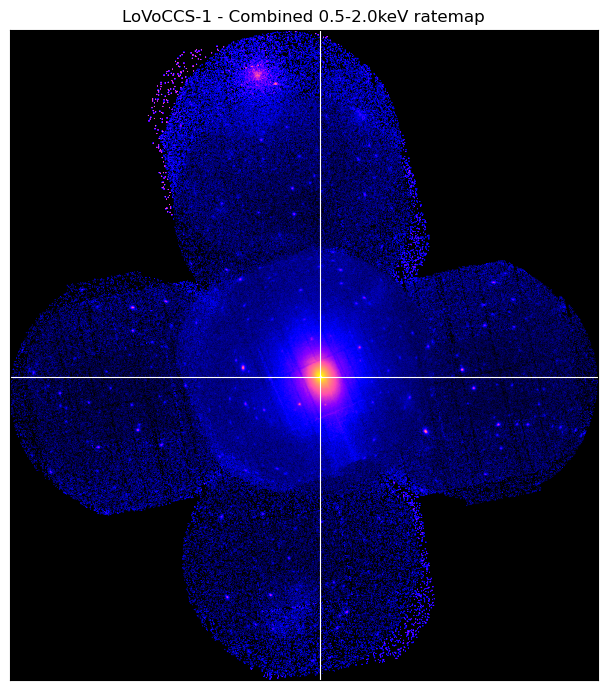

In [39]:
# The name of the cluster under investigation
cur_name = 'LoVoCCS-1'
# Telescope that took the data we're using to inspect and assign morphology class
telescope = 'xmm'

# XGA samples can be indexed by their name (in the same way dictionaries are indexed through keys)
rel_src = srcs[cur_name]

# Quickly calculate a signal to noise
rel_snr = rel_src.get_snr(snr_rad)

# Store the telescope, energy band, and SNR in the row of the results table 
#  corresponding to the current cluster
morph_class.loc[cur_name, 'telescope_examined'] = telescope
morph_class.loc[cur_name, 'examined_energy_band'] = examine_en_bnds
morph_class.loc[cur_name, 'SNR'] = rel_snr.round(2)

# Finally, fetch out the combined ratemap and display it - in some cases we will adjust the default
#  visualisation settings to make the image easier to examine (e.g. adjusting scaling min and max values)
rel_comb_rt = rel_src.get_combined_ratemaps(examine_lo_en, examine_hi_en)

# Visualise the ratemap - we don't use the standard 'view()' method of XGA ratemaps because we don't need
#  a colour bar really - we use the get_view() method as it doesn't auto apply a colour bar and we can 
#  modify the figure if necessary
plt.figure(figsize=(6, 6))
cur_ax = plt.gca()
rel_comb_rt.get_view(cur_ax, rel_src.ra_dec, zoom_in=True)
plt.tight_layout()
plt.show()

Then this cell is where we assign our classification and make any notes:

In [ ]:
# We will re-assign the name of the cluster under investigation, just in case another cell has 
#  been run for another cluster and overwritten the 'cur_name' variable
cur_name = 'LoVoCCS-1'

# The main event, the broad morphology class
morph_class.loc[cur_name, 'morph_class'] = 'CeP'